# Name : Shubhankan Shinde
# BannerWeb : 000797539
# Data Science for Business Final Project

## Students Performance Dataset 
## Project Objectives
1. Perform data exploration and preprocessing.
2. Develop a binary classification model using the K-Nearest Neighbors (K-NN) algorithm.
3. Evaluate the performance of the model using accuracy, precision, and recall.
4. Identify the best value of `K` for the K-NN algorithm.

# 1. Load and Explore Dataset

In [14]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

# Load the dataset
file_path = "C:/Users/shubhankan shinde/Desktop/Datascienceforbusiness/Cleaned_Students_Performance.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
print("Dataset Overview:\n", df.head())
print("\nDataset Info:\n")
df.info()
print("\nSummary Statistics:\n", df.describe())

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

Dataset Overview:
    gender race_ethnicity parental_level_of_education  lunch  \
0       0        group B           bachelor's degree      1   
1       0        group C                some college      1   
2       0        group B             master's degree      1   
3       1        group A          associate's degree      0   
4       1        group C                some college      1   

   test_preparation_course  math_score  reading_score  writing_score  \
0                        0          72             72             74   
1                        1          69             90             88   
2                        0          90             95             93   
3                        0          47             57             44   
4                        0          76             78             75   

   total_score  average_score  
0          218      72.666667  
1          247      82.333333  
2          278      92.666667  
3          148      49.333333  
4        

## 2. Data Exploration and Visualization

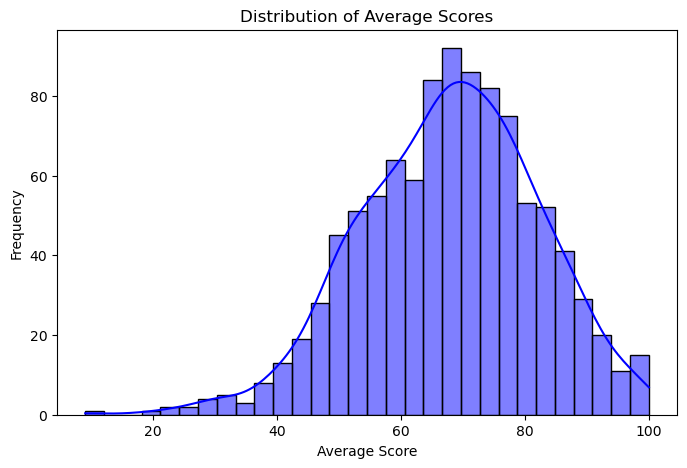

In [15]:
# Plot the distribution of 'average_score'
plt.figure(figsize=(8, 5))
sns.histplot(df['average_score'], kde=True, bins=30, color='blue')
plt.title('Distribution of Average Scores')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.show()

In [22]:
# Assuming df is already defined and contains your dataset
print("Dataset Columns:", df.columns)

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['number']).columns

print("Categorical Features:", categorical_cols)
print("Numerical Features:", numerical_cols)


Dataset Columns: Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'average_score', 'Performance'],
      dtype='object')
Categorical Features: Index(['race_ethnicity', 'parental_level_of_education', 'Performance'], dtype='object')
Numerical Features: Index(['gender', 'lunch', 'test_preparation_course', 'math_score',
       'reading_score', 'writing_score', 'total_score', 'average_score'],
      dtype='object')


## 3. Create Binary Target Variable

C:\Users\shubhankan shinde\AppData\Local\Temp\ipykernel_24788\1963145730.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Performance', data=df, palette='viridis')


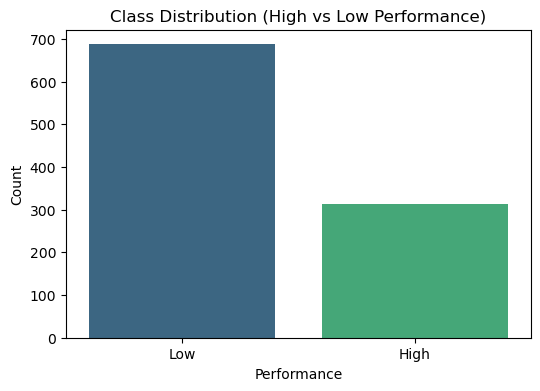

In [16]:
# Define the threshold for classification
threshold = 75
df['Performance'] = np.where(df['average_score'] > threshold, 'High', 'Low')

# Check class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Performance', data=df, palette='viridis')
plt.title('Class Distribution (High vs Low Performance)')
plt.xlabel('Performance')
plt.ylabel('Count')
plt.show()

# Drop unnecessary columns (if applicable)
X = df.drop(['average_score', 'Performance'], axis=1)  # Features
y = df['Performance']  # Target


## 4. Data Preprocessing

In [30]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# Separate features and target
X = df.drop(['average_score', 'Performance'], axis=1)  # Features
y = df['Performance']  # Target

# Separate categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['number']).columns

# Encode categorical variables using OneHotEncoder
encoder = OneHotEncoder(sparse=False, drop='first')  # Drop first to avoid multicollinearity
encoded_categorical = pd.DataFrame(encoder.fit_transform(X[categorical_cols]),
                                   columns=encoder.get_feature_names_out(categorical_cols))

# Combine encoded categorical features with numerical features
X_processed = pd.concat([X[numerical_cols].reset_index(drop=True),
                         encoded_categorical.reset_index(drop=True)], axis=1)

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)

C:\Users\shubhankan shinde\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


## 5. Split the Dataset

In [31]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Check shapes
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (700, 16)
Testing set shape: (300, 16)


## Exploratory Data Analysis (EDA)

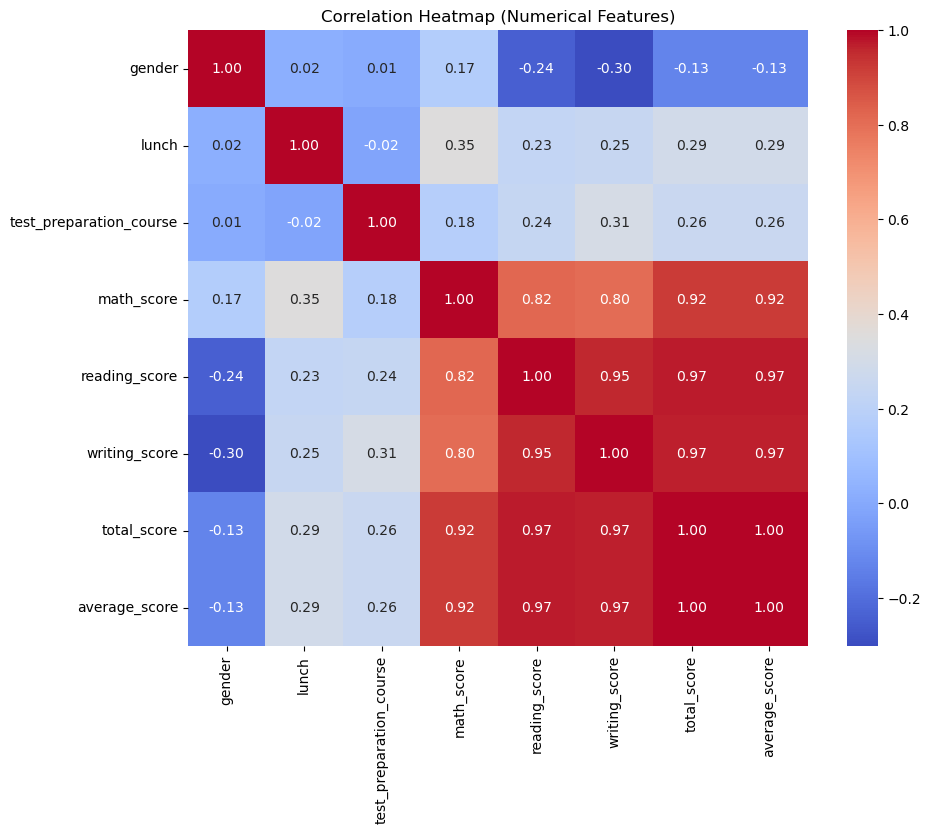

In [24]:
# Select only numerical columns
numeric_cols = df.select_dtypes(include=['number'])

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()



## 6. Train the K-NN Model

In [32]:
# Testing with different K values
k_values = [3, 5, 7]
results = []

for k in k_values:
    # Initialize the K-NN model
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Train the model
    knn.fit(X_train, y_train)
    
    # Predictions
    train_preds = knn.predict(X_train)
    test_preds = knn.predict(X_test)
    
    # Metrics
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)

    # Results
    results.append({'K': k, 'Train Accuracy': train_acc, 'Test Accuracy': test_acc})
    print(f"K={k}")
    print("Training Accuracy:", train_acc)
    print("Testing Accuracy:", test_acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, test_preds))
    print("Classification Report:\n", classification_report(y_test, test_preds))

K=3
Training Accuracy: 0.9585714285714285
Testing Accuracy: 0.9066666666666666
Confusion Matrix:
 [[ 73  21]
 [  7 199]]
Classification Report:
               precision    recall  f1-score   support

        High       0.91      0.78      0.84        94
         Low       0.90      0.97      0.93       206

    accuracy                           0.91       300
   macro avg       0.91      0.87      0.89       300
weighted avg       0.91      0.91      0.90       300

K=5
Training Accuracy: 0.9542857142857143
Testing Accuracy: 0.88
Confusion Matrix:
 [[ 68  26]
 [ 10 196]]
Classification Report:
               precision    recall  f1-score   support

        High       0.87      0.72      0.79        94
         Low       0.88      0.95      0.92       206

    accuracy                           0.88       300
   macro avg       0.88      0.84      0.85       300
weighted avg       0.88      0.88      0.88       300

K=7
Training Accuracy: 0.9342857142857143
Testing Accuracy: 0.89666666

## 7. Test Model


Summary of Results:
    K  Train Accuracy  Test Accuracy
0  3        0.958571       0.906667
1  5        0.954286       0.880000
2  7        0.934286       0.896667


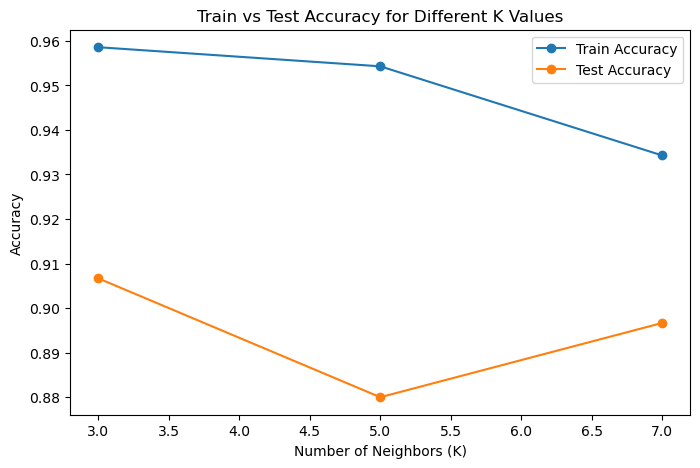

The best K value is: 3


In [33]:
# Display results
results_df = pd.DataFrame(results)
print("\nSummary of Results:\n", results_df)

# Visualize accuracy for different K values
plt.figure(figsize=(8, 5))
plt.plot(results_df['K'], results_df['Train Accuracy'], label='Train Accuracy', marker='o')
plt.plot(results_df['K'], results_df['Test Accuracy'], label='Test Accuracy', marker='o')
plt.title('Train vs Test Accuracy for Different K Values')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Best K (based on testing accuracy)
best_k = results_df.loc[results_df['Test Accuracy'].idxmax(), 'K']
print(f"The best K value is: {best_k}")


## 8. Detailed Confusion Matrix for Best K

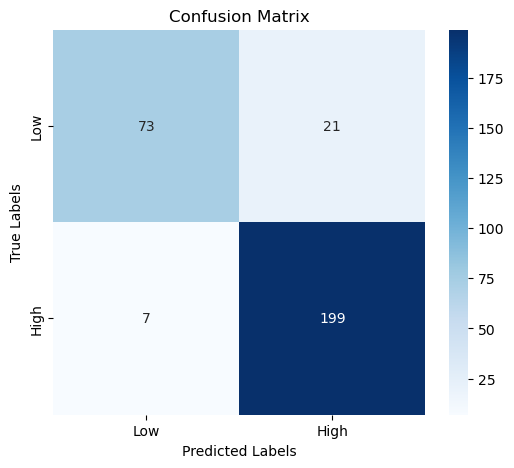

Precision: 0.91, Recall: 0.78


In [28]:
# Retrain with the best K
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)
final_preds = best_knn.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Additional metrics
precision = precision_score(y_test, final_preds, pos_label='High')
recall = recall_score(y_test, final_preds, pos_label='High')
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}")
